# Combined Chromatin Model
February 9, 2024

In this notebook, we will construct and test out the class that will combine the two chromatin deconvolution replicate models.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [107]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config, \
    load_yl_replicate2_rg1_alpha_vst_config

config1 = load_yl_replicate1_rg1_alpha_vst_config()
config2 = load_yl_replicate2_rg1_alpha_vst_config()

In [108]:
from cc_src.combined_chromatin_model import CombinedChromatinModel

combined_model = CombinedChromatinModel(config1, config2)

In [109]:
gene_name = "CLB2"
combined_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)
Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (15, 27)


In [110]:
combined_model.setup_deconv_model()

In [113]:
combined_model.deconvolve_find_optimal_gamma()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.8177
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.8977, rate = 4.4
  ...   gm = 0.0050, rn = 2.1792, rate = 19.89, time = 00:00:39.74
  ...   gm = 0.0026, rn = 2.0848, rate = 14.70, time = 00:00:49.75
  ...   gm = 0.0013, rn = 1.9994, rate = 10.00, time = 00:00:59.20
  ...  search right, rn_goal = 2.5448, rate = 40.0
  ... rn range: [1.9994, 2.2844]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 1.9994, rate = 10.00, time = 00:01:18.06
  ...   gm = 0.0022, rn = 2.0626, rate = 13.47, time = 00:01:28.07
  ...   gm = 0.0031, rn = 2.1108, rate = 16.13, time = 00:01:38.17
  ...   gm = 0.0039, rn = 2.1511, rate = 18.34, time = 00:01:48.20
  ...   gm = 0.0048, rn = 2.1734, rate = 19.57, time = 00:01:57.73
  ...   gm = 0.0057, rn = 2.1954, rate = 20.78, time = 00:02:06.85
  ...   gm = 0.0065, 

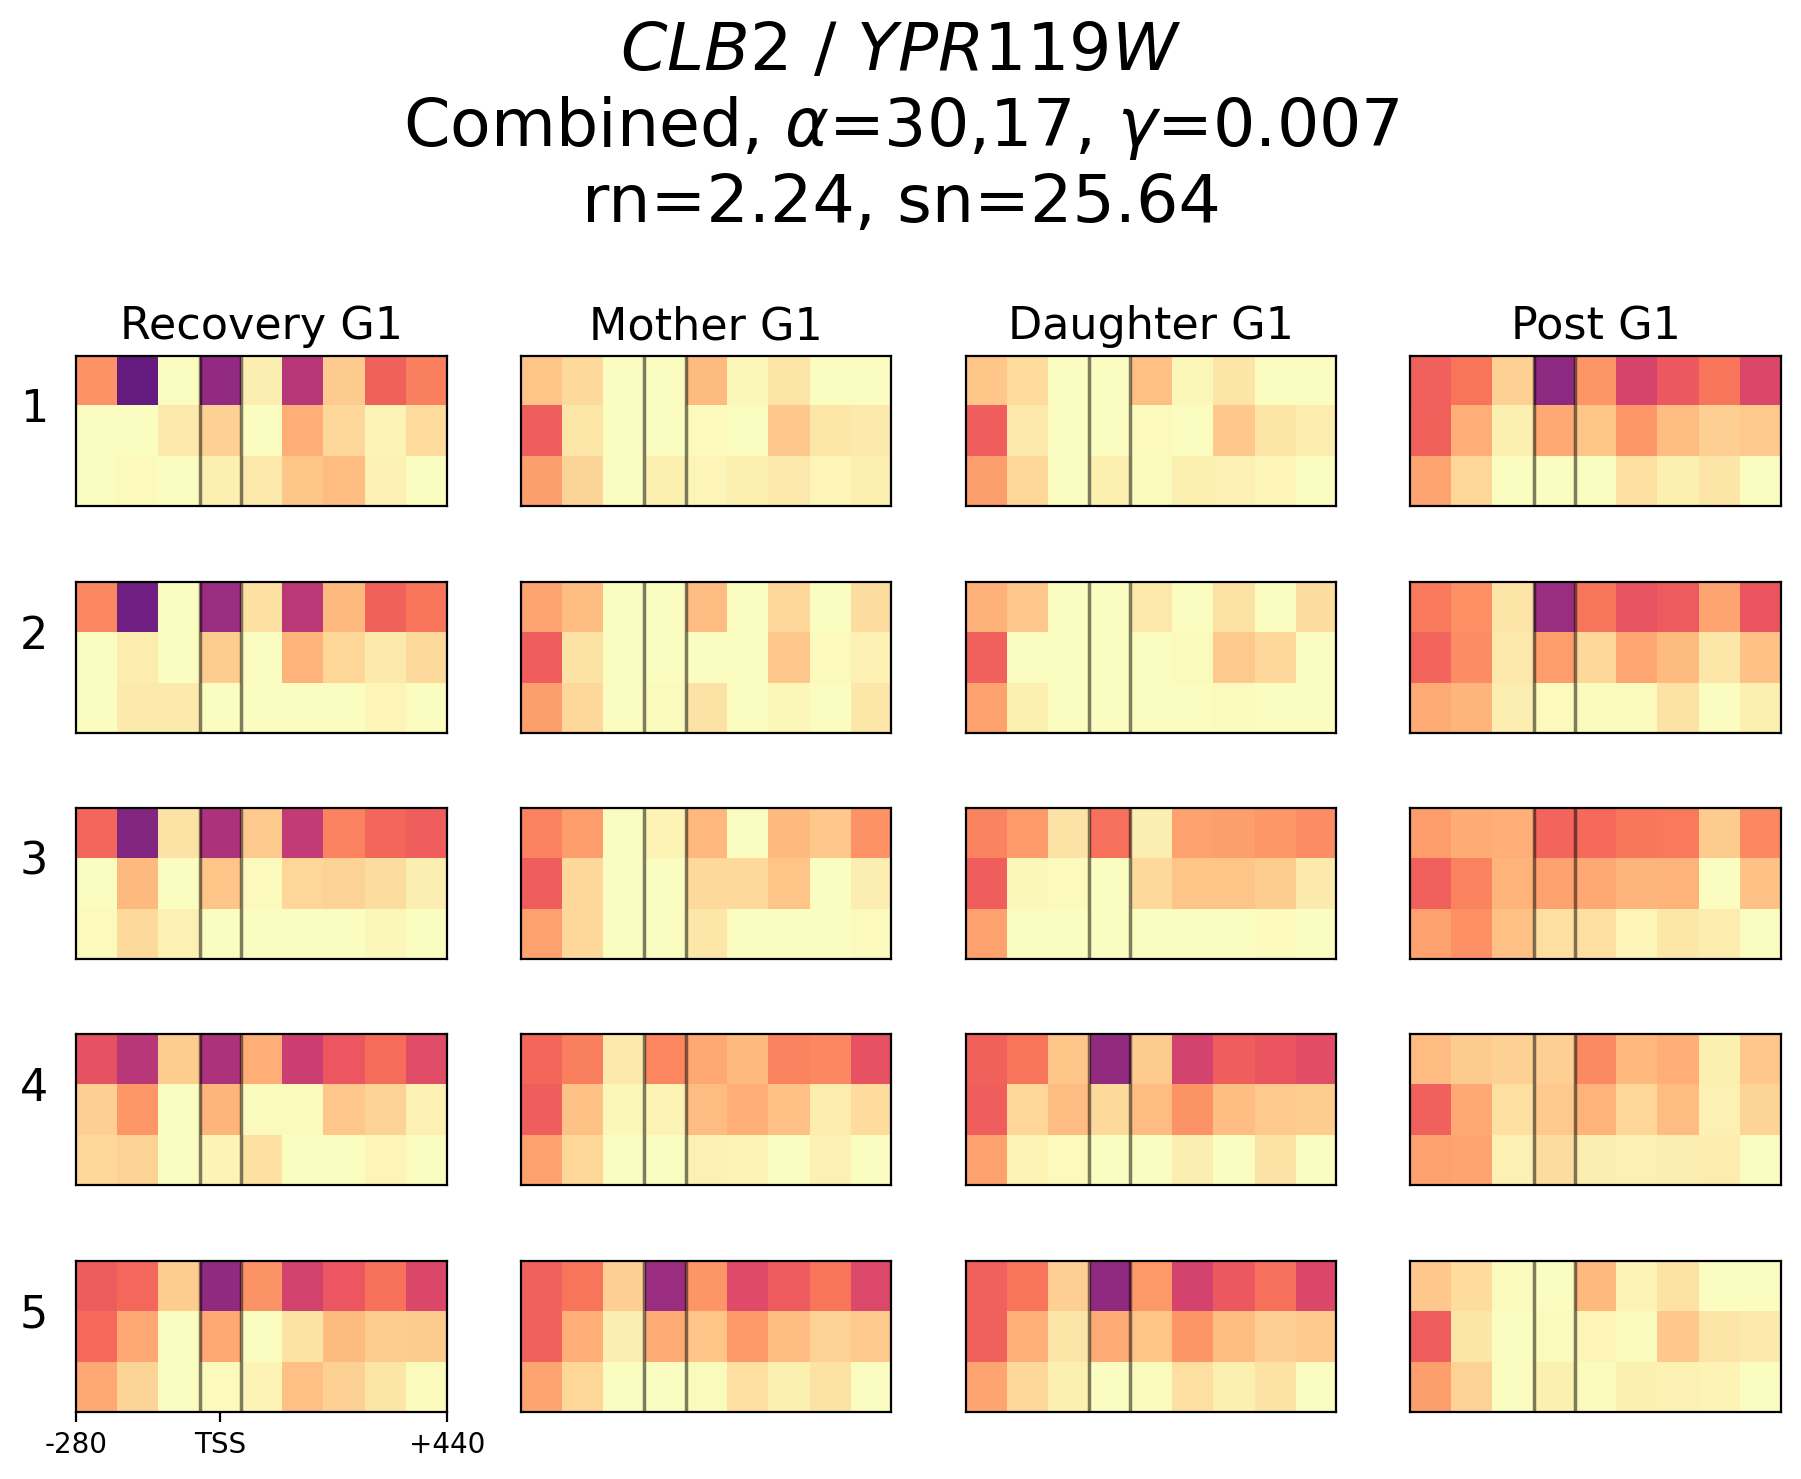

In [115]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped()

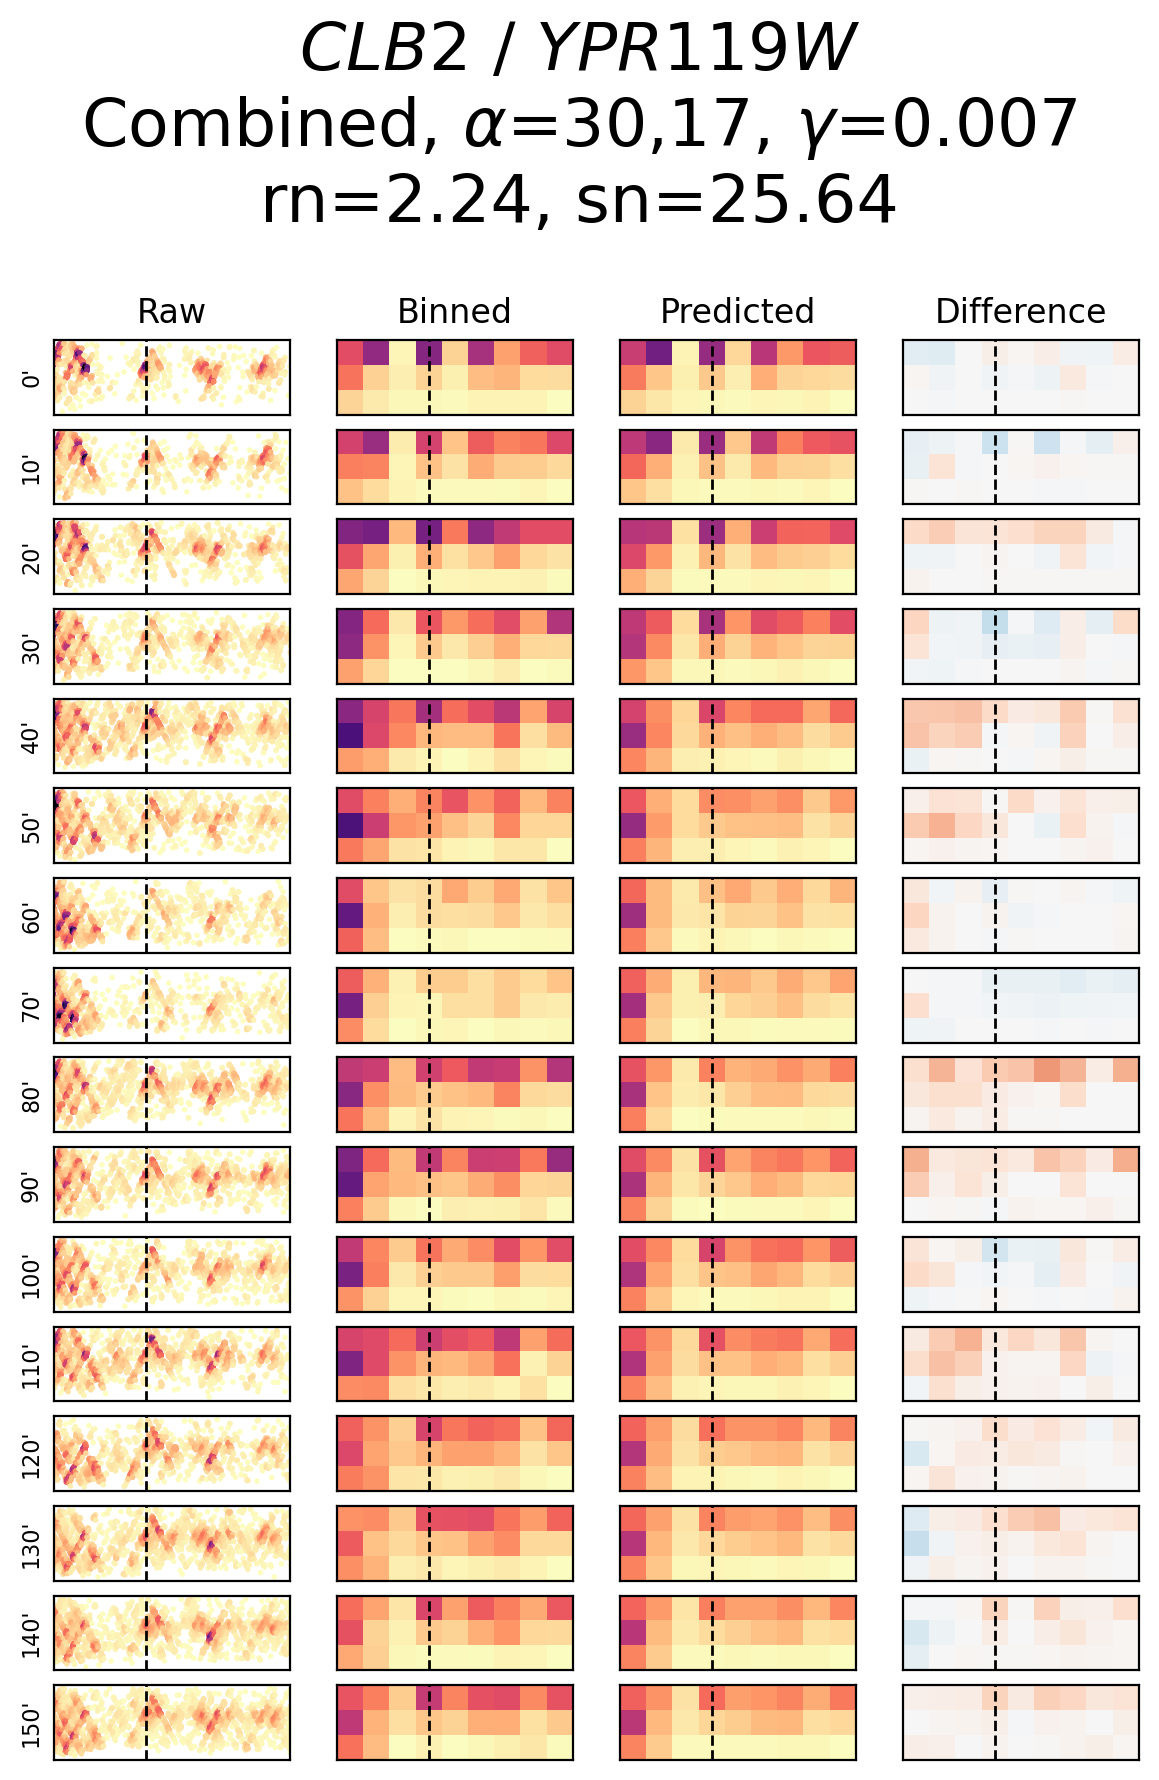

In [116]:
fig = combined_model.plot_raw_prediction(1)

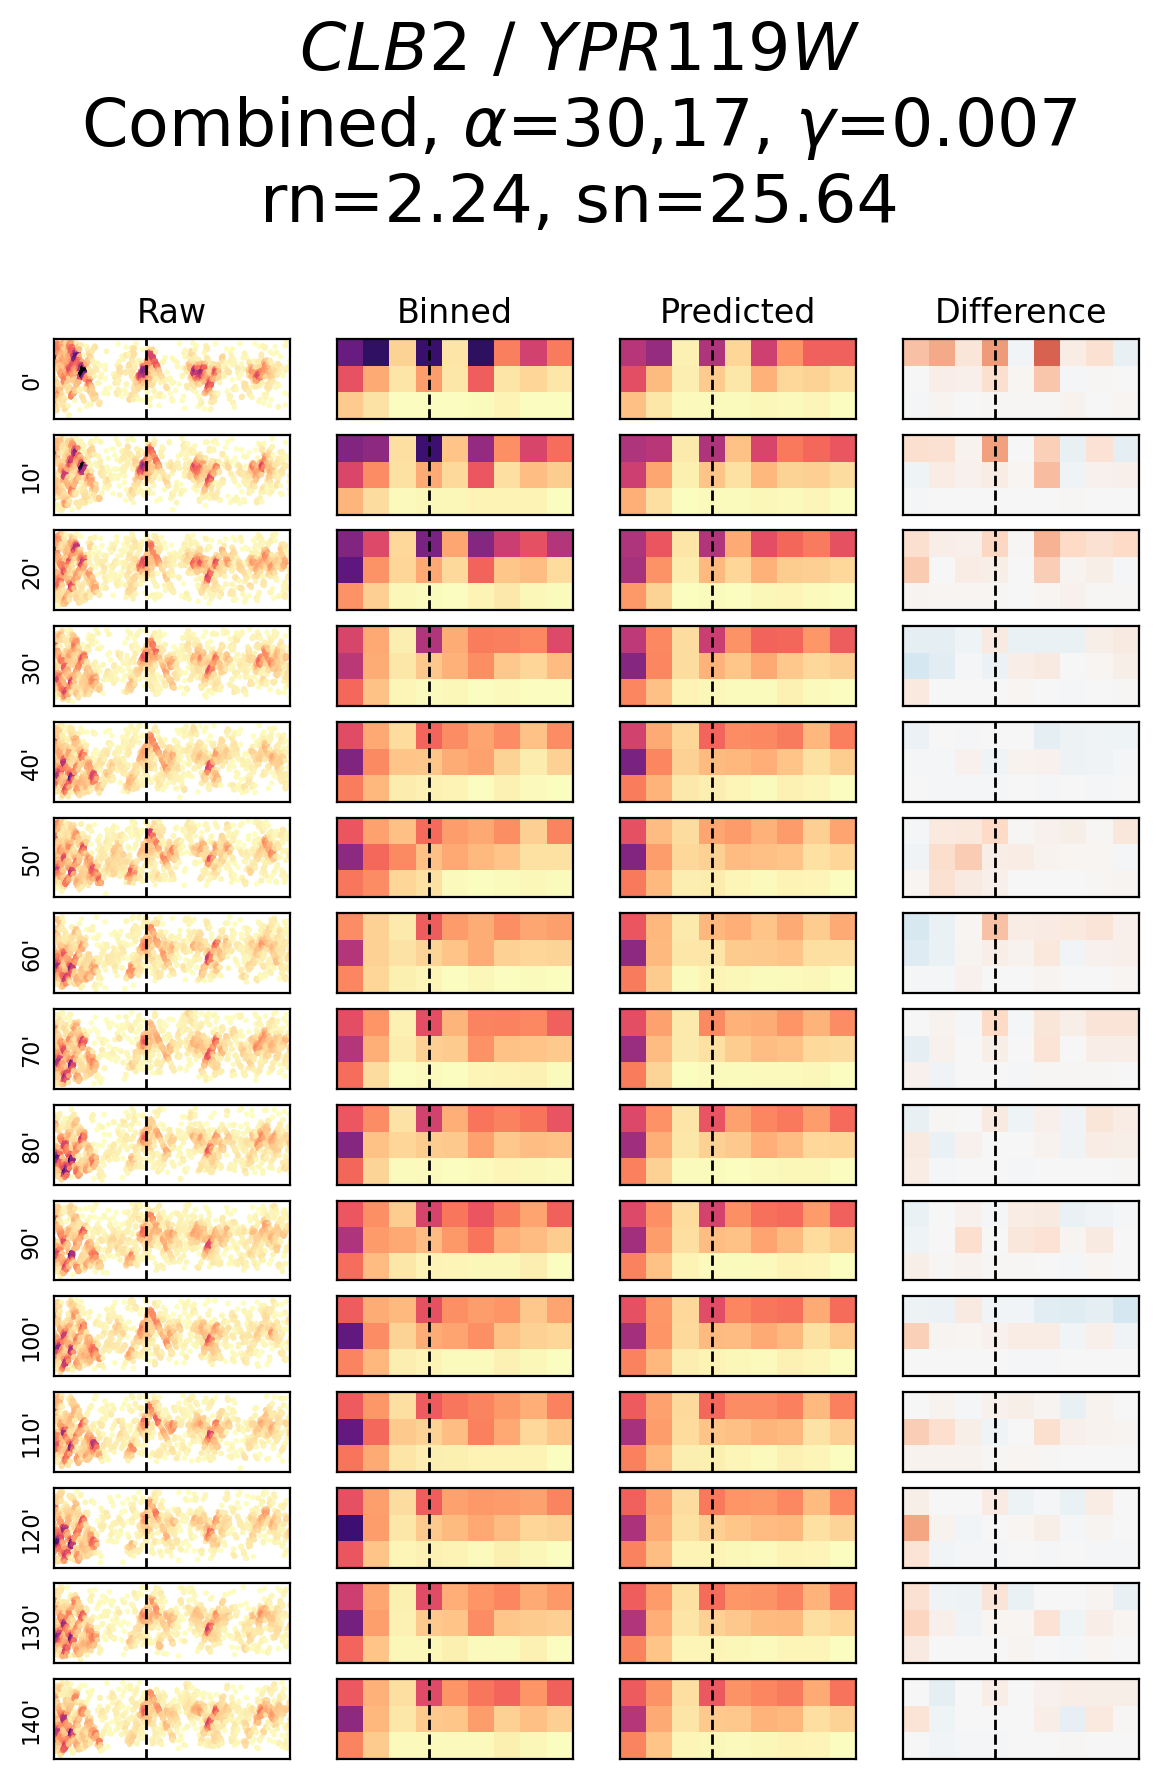

In [117]:
fig = combined_model.plot_raw_prediction(2)